In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

df.head(80)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582.0,0,20.0,1,265000.00,1.9,130.0,1,0,4.0,1
1,55.0,0,7861.0,0,38.0,0,263358.03,1.1,136.0,1,0,6.0,1
2,65.0,0,146.0,0,20.0,0,162000.00,1.3,129.0,1,1,7.0,1
3,50.0,1,NaN,0,20.0,0,210000.00,1.9,137.0,1,0,7.0,1
4,65.0,1,160.0,1,20.0,0,327000.00,2.7,116.0,0,0,8.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,60.0,1,47.0,0,20.0,0,204000.00,0.7,139.0,1,1,73.0,1
76,70.0,0,92.0,0,60.0,1,317000.00,0.8,140.0,0,1,74.0,0
77,42.0,0,102.0,1,40.0,0,237000.00,1.2,140.0,1,0,74.0,0
78,75.0,1,203.0,1,38.0,1,283000.00,0.6,131.0,1,1,74.0,0


In [18]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Rows: 299
Columns: 13

Data Types:
age                         float64
anaemia                       int64
creatinine_phosphokinase    float64
diabetes                      int64
ejection_fraction           float64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                float64
sex                           int64
smoking                       int64
time                        float64
DEATH_EVENT                   int64
dtype: object

Missing Values:
age                         0
anaemia                     0
creatinine_phosphokinase    8
diabetes                    0
ejection_fraction           1
high_blood_pressure         0
platelets                   3
serum_creatinine            0
serum_sodium                5
sex                         0
smoking                     0
time                        2
DEATH_EVENT                 0
dtype: int64


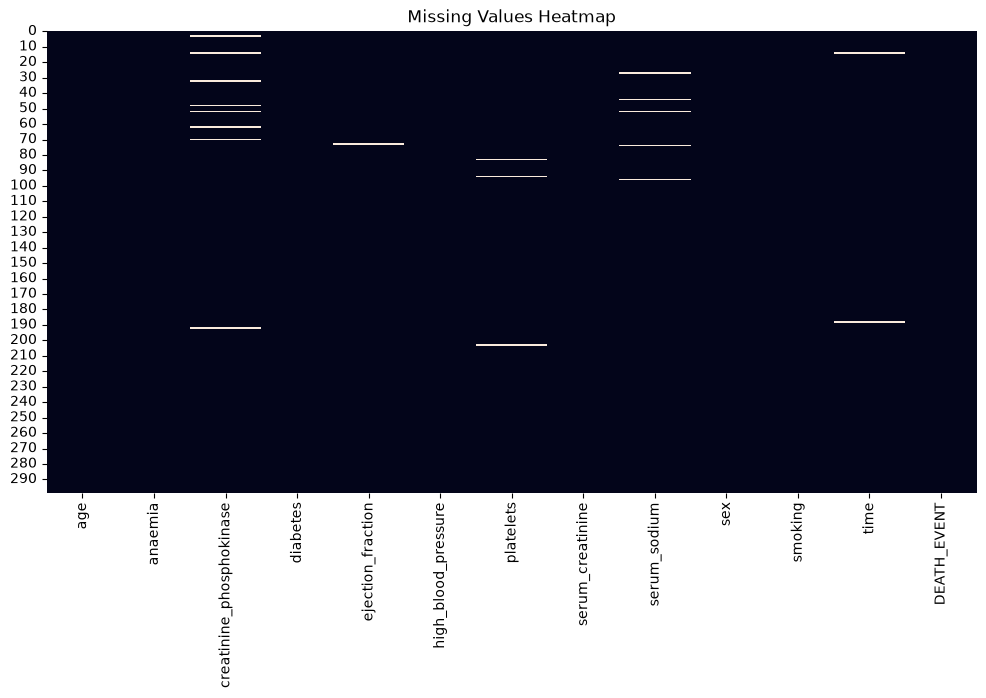

In [19]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

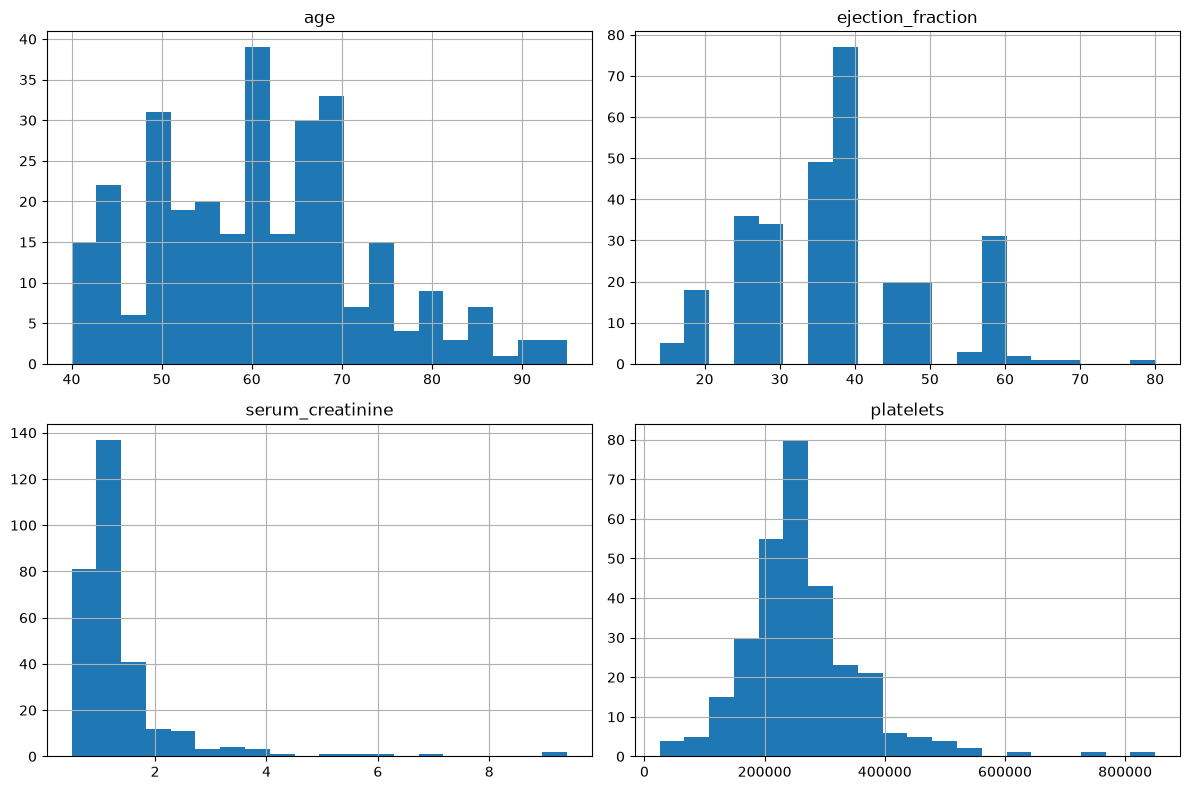

In [20]:
num_cols = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "platelets"
]

df[num_cols].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

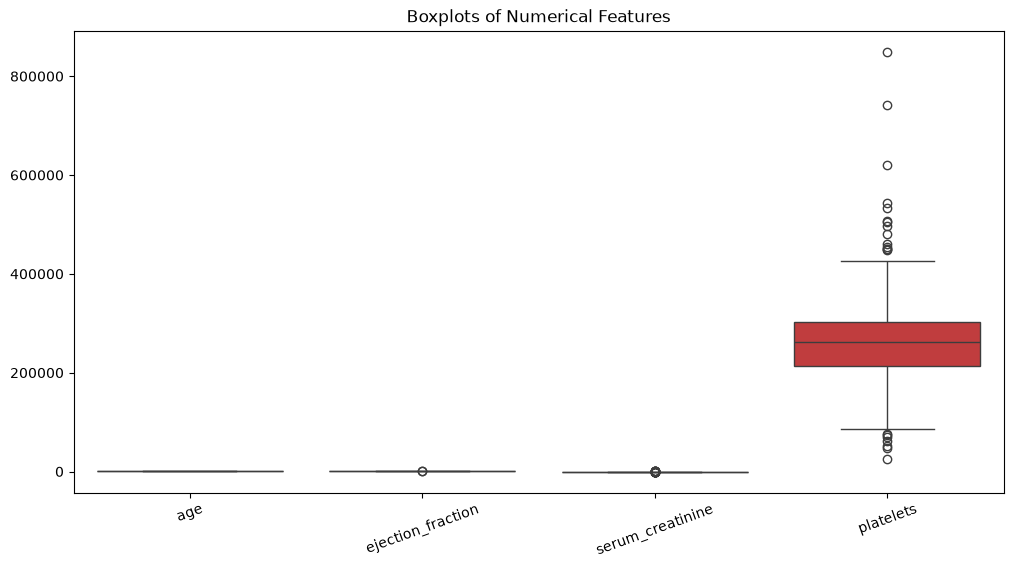

In [21]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols])
plt.title("Boxplots of Numerical Features")
plt.xticks(rotation=20)
plt.show()

In [22]:
num_cols_all = df.select_dtypes(include=np.number).columns

cat_cols = df.select_dtypes(exclude=np.number).columns

for col in num_cols_all:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [23]:
numeric_features = df.select_dtypes(include=np.number).columns

Q1 = df[numeric_features].quantile(0.25)
Q3 = df[numeric_features].quantile(0.75)
IQR = Q3 - Q1

mask = ~(
    (df[numeric_features] < (Q1 - 1.5 * IQR)) |
    (df[numeric_features] > (Q3 + 1.5 * IQR))
).any(axis=1)

df_clean = df[mask].copy()

print("Original rows:", len(df))
print("Rows after outlier removal:", len(df_clean))
print("Outliers removed:", len(df) - len(df_clean))

Original rows: 299
Rows after outlier removal: 222
Outliers removed: 77


In [24]:
invalid_age = df_clean["age"] <= 0

print("Invalid age values:", invalid_age.sum())

df_clean.loc[invalid_age, "age"] = df_clean["age"].median()

print("Minimum age:", df_clean["age"].min())

Invalid age values: 0
Minimum age: 40.0


In [25]:
df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=[0, 40, 60, np.inf],
    labels=["<40", "40-60", ">60"]
)

risk_product = (
    df_clean["ejection_fraction"] *
    df_clean["serum_creatinine"]
)

df_clean["risk_score"] = (
    (risk_product - risk_product.min()) /
    (risk_product.max() - risk_product.min())
)

df_clean[
    ["age", "age_group", "ejection_fraction",
     "serum_creatinine", "risk_score"]
].head()

,age,age_group,ejection_fraction,serum_creatinine,risk_score
0,75.0,>60,20.0,1.9,0.310545
2,65.0,>60,20.0,1.3,0.171495
3,50.0,40-60,20.0,1.9,0.310545
5,90.0,>60,40.0,2.1,0.843569
6,75.0,>60,15.0,1.2,0.078795


In [26]:
categorical_cols = ["sex", "smoking", "age_group"]

df_encoded = pd.get_dummies(
    df_clean,
    columns=categorical_cols,
    dtype=int
)

df_encoded.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,time,DEATH_EVENT,risk_score,sex_0,sex_1,smoking_0,smoking_1,age_group_<40,age_group_40-60,age_group_>60
0,75.0,0,582.0,0,20.0,1,265000.0,1.9,130.0,4.0,1,0.310545,0,1,1,0,0,0,1
2,65.0,0,146.0,0,20.0,0,162000.0,1.3,129.0,7.0,1,0.171495,0,1,0,1,0,0,1
3,50.0,1,253.0,0,20.0,0,210000.0,1.9,137.0,7.0,1,0.310545,0,1,1,0,0,1,0
5,90.0,1,47.0,0,40.0,1,204000.0,2.1,132.0,8.0,1,0.843569,0,1,0,1,0,0,1
6,75.0,1,246.0,0,15.0,0,127000.0,1.2,137.0,10.0,1,0.078795,0,1,1,0,0,0,1


In [27]:
scaler = MinMaxScaler()

numeric_cols = df_encoded.select_dtypes(
    include=np.number
).columns

df_encoded[numeric_cols] = scaler.fit_transform(
    df_encoded[numeric_cols]
)

df_encoded.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,time,DEATH_EVENT,risk_score,sex_0,sex_1,smoking_0,smoking_1,age_group_<40,age_group_40-60,age_group_>60
0,0.636364,0.0,0.470990,0.0,0.117647,1.0,0.468852,0.866667,0.210526,0.000000,1.0,0.310545,0.0,1.0,1.0,0.0,0.0,0.0,1.0
2,0.454545,0.0,0.098976,0.0,0.117647,0.0,0.131148,0.466667,0.157895,0.010676,1.0,0.171495,0.0,1.0,0.0,1.0,0.0,0.0,1.0
3,0.181818,1.0,0.190273,0.0,0.117647,0.0,0.288525,0.866667,0.578947,0.010676,1.0,0.310545,0.0,1.0,1.0,0.0,0.0,1.0,0.0
5,0.909091,1.0,0.014505,0.0,0.509804,1.0,0.268852,1.000000,0.315789,0.014235,1.0,0.843569,0.0,1.0,0.0,1.0,0.0,0.0,1.0
6,0.636364,1.0,0.184300,0.0,0.019608,0.0,0.016393,0.400000,0.578947,0.021352,1.0,0.078795,0.0,1.0,1.0,0.0,0.0,0.0,1.0


In [28]:
before_stats = df[num_cols].agg(
    ["mean", "median", "std"]
).T

after_stats = df_clean[num_cols].agg(
    ["mean", "median", "std"]
).T

print("Before Cleaning:")
display(before_stats)

print("\nAfter Cleaning:")
display(after_stats)

Before Cleaning:


,mean,median,std
age,60.833893,60.0,11.894809
ejection_fraction,38.043478,38.0,11.814624
serum_creatinine,1.393880,1.1,1.034510
platelets,263613.882107,262500.0,97545.681711



After Cleaning:


,mean,median,std
age,60.681685,60.0,11.923157
ejection_fraction,37.972973,38.0,11.615608
serum_creatinine,1.127477,1.1,0.328760
platelets,255976.588153,262500.0,67048.069803


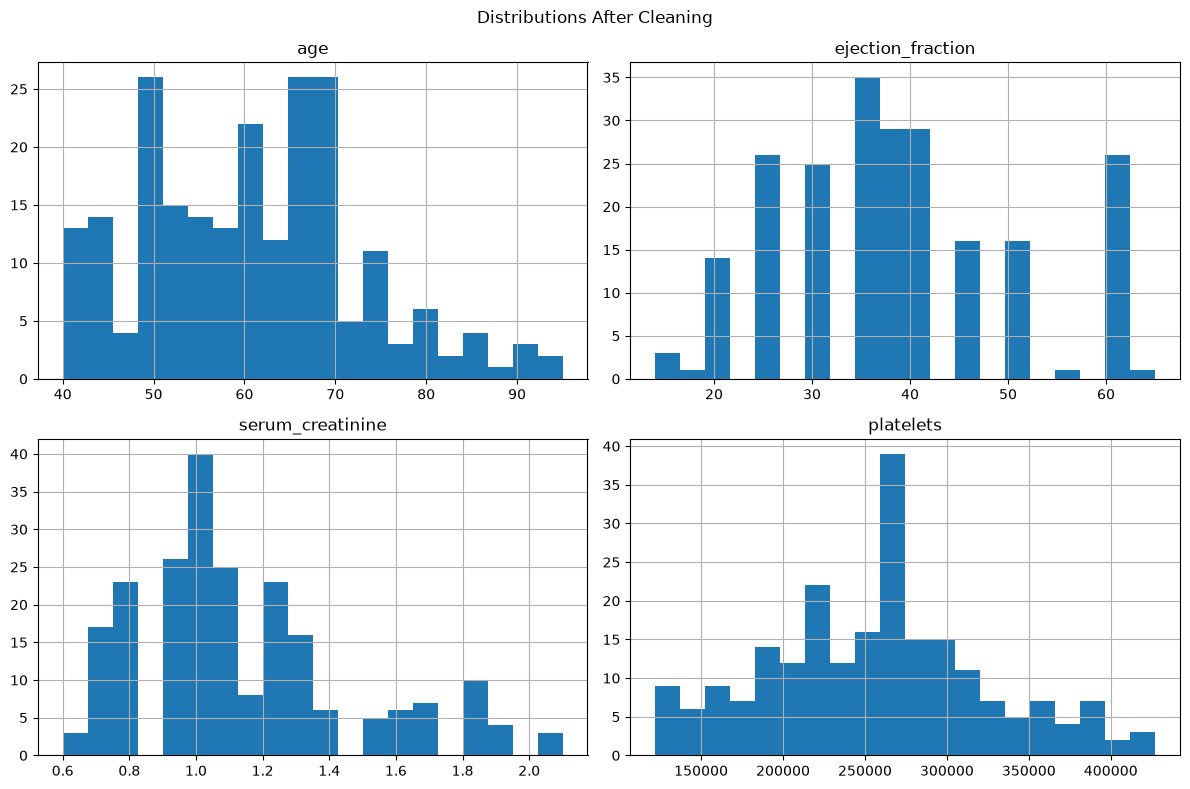

In [29]:
df_clean[num_cols].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle("Distributions After Cleaning")
plt.tight_layout()
plt.show()

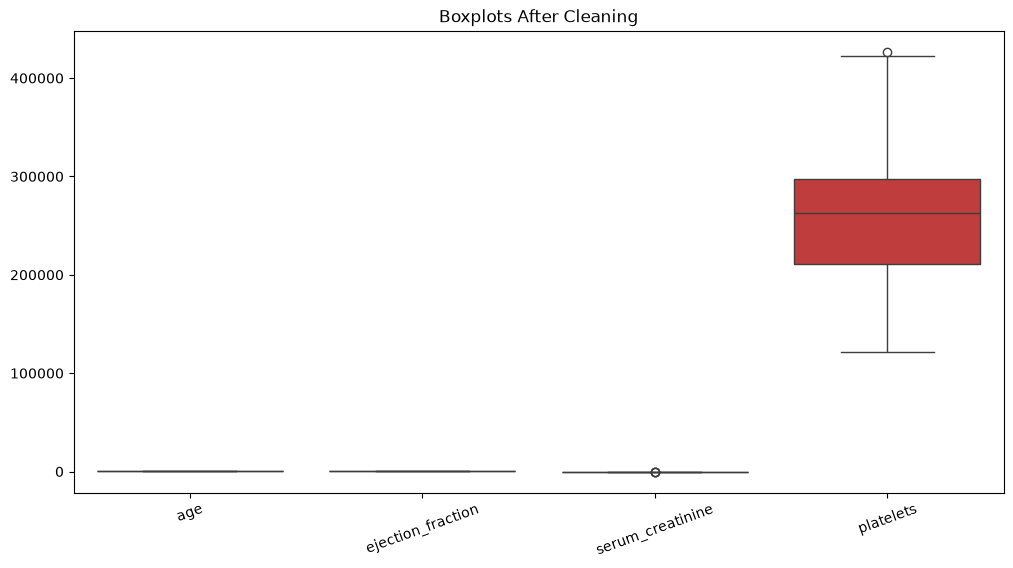

In [30]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df_clean[num_cols])

plt.title("Boxplots After Cleaning")
plt.xticks(rotation=20)
plt.show()

In [31]:
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

print("\nTotal missing values:",
      df_clean.isnull().sum().sum())

Missing values after cleaning:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
age_group                   0
risk_score                  0
dtype: int64

Total missing values: 0


In [32]:
print("Final dataset shape:", df_encoded.shape)

df_encoded.head()

Final dataset shape: (222, 19)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,time,DEATH_EVENT,risk_score,sex_0,sex_1,smoking_0,smoking_1,age_group_<40,age_group_40-60,age_group_>60
0,0.636364,0.0,0.470990,0.0,0.117647,1.0,0.468852,0.866667,0.210526,0.000000,1.0,0.310545,0.0,1.0,1.0,0.0,0.0,0.0,1.0
2,0.454545,0.0,0.098976,0.0,0.117647,0.0,0.131148,0.466667,0.157895,0.010676,1.0,0.171495,0.0,1.0,0.0,1.0,0.0,0.0,1.0
3,0.181818,1.0,0.190273,0.0,0.117647,0.0,0.288525,0.866667,0.578947,0.010676,1.0,0.310545,0.0,1.0,1.0,0.0,0.0,1.0,0.0
5,0.909091,1.0,0.014505,0.0,0.509804,1.0,0.268852,1.000000,0.315789,0.014235,1.0,0.843569,0.0,1.0,0.0,1.0,0.0,0.0,1.0
6,0.636364,1.0,0.184300,0.0,0.019608,0.0,0.016393,0.400000,0.578947,0.021352,1.0,0.078795,0.0,1.0,1.0,0.0,0.0,0.0,1.0
